### DOE analysis on /theta (transconjugant rate score)

In [2]:
import pandas as pd 
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from numpy.random import default_rng
import os
import arviz as az

# Import functions
from cmdstanpy import CmdStanModel
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions


import cmdstanpy
import os
from pathlib import Path

import os, sys
from pathlib import Path
def set_project_root():
        
    # Find and navigate to Progetto_Bayesian_Statistics
    current = Path.cwd()

    # Check if we're already there
    if current.name == 'Progetto_Bayesian_Statistics':
        print(f"Already in project root: {current}")
    else:
        # Search up to parent directories
        for parent in [current] + list(current.parents):
            if parent.name == 'Progetto_Bayesian_Statistics':
                os.chdir(parent)
                print(f"Changed to: {parent}")
                break
        else:
            raise FileNotFoundError("Progetto_Bayesian_Statistics folder not found")

    # Verify
    assert Path('src').exists(), "src/ folder not found"
    print(f"Current directory: {os.getcwd()}")
    print(f"Contents: {os.listdir()}")


    # Create ./stan folder if does not exists
    STAN_PATH = "./src/stan_models/"
    print(cmdstanpy.cmdstan_path())
    return STAN_PATH

STAN_PATH = set_project_root()
print("cwd:", os.getcwd())
print("first sys.path entries:")
for p in sys.path[:5]:
    print("  ", p)

print("project root guess:", Path().resolve())
print("exists ./src ?", (Path().resolve() / "src").exists())

from src.utils.utils import *

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Changed to: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
Current directory: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
Contents: ['materials', '.DS_Store', 'requirements.txt', 'README.md', 'results', '.gitignore', 'requirements.bk.txt', '.git', 'results1', 'data', 'src']
/Users/sararedaelli/.cmdstan/cmdstan-2.37.0
cwd: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
first sys.path entries:
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python313.zip
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload
   
   /Users/sararedaelli/Library/Python/3.13/lib/python/site-packages
project root guess: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
exists ./src ? True


In [3]:
data, data_donors = transform_data()
glm_data, X_D = get_glm_data(data, data_donors)

[1 2 3 4 5 6 7 8]
[1 2 3 4 5 6 7 8]


/Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics/src/utils/utils.py:70: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Control'] = data['Control'].replace({'Yes': 1, 'No': 0})


In [4]:
model_names = [("ab_baseline_simple_poi.stan", {}), ("ab_lasso.stan", {}), ("ab_horseshoe.stan", {}), ("ab_regularized_horseshoe.stan", {"p0": 2}), ("ab_r2d2.stan", {"R2_mean": 0.5,"R2_prec": 2.0, "cons_D2": 0.5})]

models = {}
for key in model_names:
    glm = CmdStanModel(stan_file=f"{STAN_PATH}/{key[0]}")
    for x in X_D:
        models[(key[0], tuple(key[1].items()), x)] = {"model": glm, "X": X_D[x]}
        new_data = glm_data.copy()
        new_data.update({"X": X_D[x], "p": X_D[x].shape[1]})
        new_data.update(key[1])
        models[(key[0], tuple(key[1].items()), x)]["data"] = new_data

In [5]:
import os
for key in models:
    filename = f"{'_'.join(str(k) for k in key)}.nc"
    models[key]["az"] = az.from_netcdf(f"./results/ab/{filename}")

##### Reconstruct the posterior mean rate per observation

In [6]:
def get_posterior_rate_means(idata, X, idx_experiment, idx_experiment_replica, one_based=True):
    exp_idx = np.asarray(idx_experiment)
    rep_idx = np.asarray(idx_experiment_replica)

    # Stan indices are usually 1..I, 1..J
    if one_based:
        exp_idx = exp_idx - 1
        rep_idx = rep_idx - 1


    post = idata.posterior
    beta = post["beta"]
    b_re = post["beta_random"]

    beta_np = beta.stack(sample=("chain", "draw")).values      # (sample, p)
    b_re_np = b_re.stack(sample=("chain", "draw")).values      # (sample, I, J)
    
    X_np    = np.asarray(X)                                   # (obs, p)
    beta_np = beta_np.T                       # (24000, 4)
    b_re_np  = np.transpose(b_re_np, (2,0,1)) # (24000, 8, 3)


    # fixed part: (sample, obs)
    eta_np = beta_np @ X_np.T

    # random intercept per obs: (sample, obs)
    # advanced indexing: exp_idx and rep_idx are (obs,)
    b_obs_np = b_re_np[:, exp_idx, rep_idx]

    # combine + exp
    mu_np = np.exp(eta_np + b_obs_np)

    # posterior mean per obs: (obs,)
    rate_mean = mu_np.mean(axis=0)

    #compute log rate mean
    log_rate_mean = np.log(rate_mean)

    return log_rate_mean


In [7]:
#apply function to the simple model with X simple
get_posterior_rate_means(models[("ab_baseline_simple_poi.stan", tuple({}.items()), "X")]["az"], 
                         models[("ab_baseline_simple_poi.stan", tuple({}.items()), "X")]["X"], glm_data["idx_experiment"], glm_data["idx_experiment_replica"])

array([ -9.61302869,  -9.61302869,  -9.61302869,  -9.61302869,
        -9.61302869,  -9.61302869,  -9.61364136,  -9.61364136,
        -9.61364136,  -9.61364136,  -9.61364136,  -9.61364136,
       -10.93331473, -10.93331473, -10.93331473, -10.93331473,
       -10.93331473, -10.93331473, -10.93331473, -10.93331473,
       -10.93331473, -10.93392182, -10.93392182, -10.93392182,
       -10.93392182, -10.93392182, -10.93392182, -10.93392182,
       -10.93392182, -10.93392182, -10.5386652 , -10.5386652 ,
       -10.5386652 , -10.5386652 , -10.5386652 , -10.5386652 ,
       -10.5386652 , -10.5386652 , -10.5386652 , -10.54352934,
       -10.54352934, -10.54352934, -10.54352934, -10.54352934,
       -10.54352934, -10.54352934, -10.54352934, -10.54352934,
       -10.69028502, -10.69028502, -10.69028502, -10.69028502,
       -10.69028502, -10.69028502, -10.69028502, -10.69028502,
       -10.69028502, -10.69513064, -10.69513064, -10.69513064,
       -10.69513064, -10.69513064, -10.69513064, -10.69

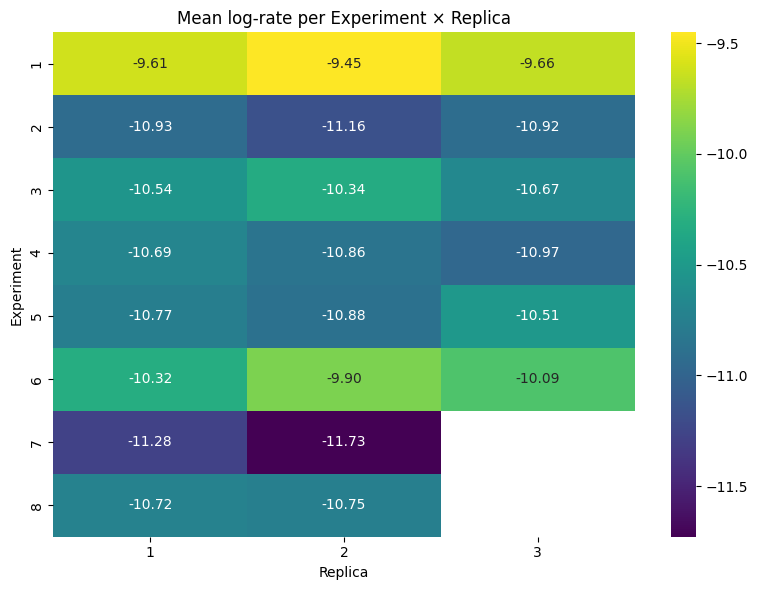

In [8]:
import seaborn as sns

df = pd.DataFrame({
    "idx_experiment": glm_data["idx_experiment"],
    "idx_experiment_replica": glm_data["idx_experiment_replica"],
    "log_rate_mean": np.asarray(
        get_posterior_rate_means(
            models[("ab_baseline_simple_poi.stan", tuple({}.items()), "X")]["az"], 
            models[("ab_baseline_simple_poi.stan", tuple({}.items()), "X")]["X"], 
            glm_data["idx_experiment"], 
            glm_data["idx_experiment_replica"]
        )
    )
})

# media per (experiment × replica) + trasformazione in matrice
heatmap_data = (
    df.groupby(["idx_experiment", "idx_experiment_replica"])["log_rate_mean"]
      .mean()
      .unstack()
)

plt.figure(figsize=(8,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Mean log-rate per Experiment × Replica")
plt.xlabel("Replica")
plt.ylabel("Experiment")
plt.tight_layout()
plt.show()






### Log_rate from original data 

In [17]:

# 1) Compute donor mean per (Experiment, Replica)
data_donors["Real Counts"]=data_donors["Count"]/glm_data["rho_donor"]
donor_mean_experiment = (
    data_donors
    .groupby(["Idx Experiment", "Idx Replica Experiment"])["Real Counts"]
    .mean()
)

# 2) Build lookup keys for each observation
keys = list(zip(glm_data["idx_experiment"], 
                glm_data["idx_experiment_replica"]))

# 3) Extract donor mean aligned to each sample
donor_mean = donor_mean_experiment.loc[keys].values





# 4) Compute observed real rate
real_counts = glm_data["Y"] / glm_data["rho_trasc"]

#keep only positive real_counts 
mask = real_counts > 0

# 5) Compute log-rate from data
log_rate_data = np.log(real_counts[mask]) - np.log(donor_mean[mask])

# Optional sanity check
print("Any NaN in donor_mean?", np.isnan(donor_mean).any())
print("Any inf in log_rate_data?", np.isinf(log_rate_data).any())

log_rate_data


Any NaN in donor_mean? False
Any inf in log_rate_data? False


array([-10.29965027, -10.38666164, -10.48197182, -10.19428975,
        -9.78882464,  -8.63614513, -10.58733234, -10.51587338,
       -10.27225129, -10.48197182,  -9.63467396, -10.48197182,
       -11.12971097, -11.06205232, -11.24624478, -12.51600533,
       -13.43229606, -13.02683095, -11.82285815, -11.37178253,
       -11.00749333, -11.01192793, -12.73914888, -12.17953309,
       -11.72754797, -10.1266311 ,  -9.98848077, -10.22379485,
       -10.4267357 , -10.20359214, -10.56026709,  -9.70281686,
        -9.53576277,  -9.69677454,  -9.73358852,  -9.94122788,
        -9.86711991, -10.20359214, -10.20359214, -10.20359214,
       -10.77618785, -10.67700753, -10.78093845, -11.34055424,
       -12.21602298, -12.7268486 , -10.59861689, -10.63910826,
       -10.83977895, -11.11741069, -11.42756562, -11.34055424,
       -10.82972862, -10.82972862, -10.02127059, -10.71441777,
       -10.20359214, -10.20359214, -10.56026709, -10.56026709,
       -10.20359214,  -9.98779466, -10.07480604, -10.20

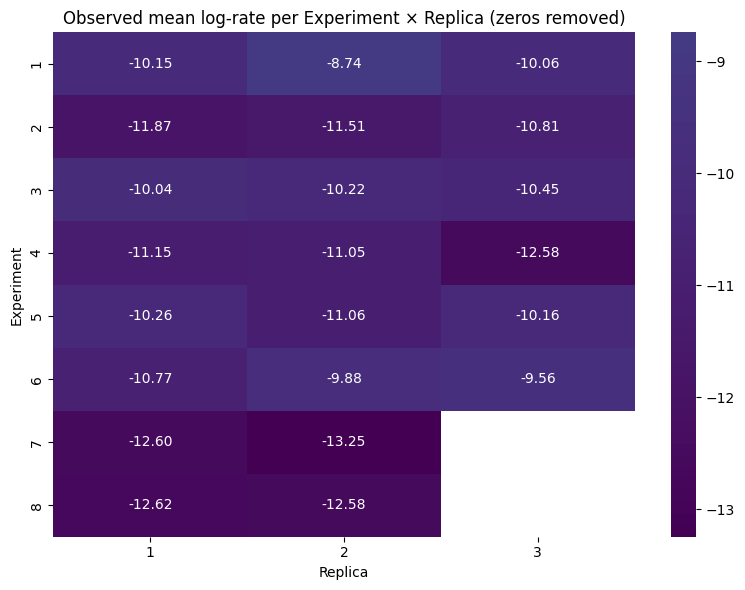

In [20]:
# 4) Create dataframe for aggregation (masked version)
df_heat = pd.DataFrame({
    "idx_experiment": glm_data["idx_experiment"][mask],
    "idx_experiment_replica": glm_data["idx_experiment_replica"][mask],
    "log_rate_data": log_rate_data
})

# 5) Compute mean log-rate per (experiment × replica)
heatmap_data = (
    df_heat
    .groupby(["idx_experiment", "idx_experiment_replica"])["log_rate_data"]
    .mean()
    .unstack()
)

# 6) Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    center=0
)

plt.title("Observed mean log-rate per Experiment × Replica (zeros removed)")
plt.xlabel("Replica")
plt.ylabel("Experiment")
plt.tight_layout()
plt.show()



### Compare

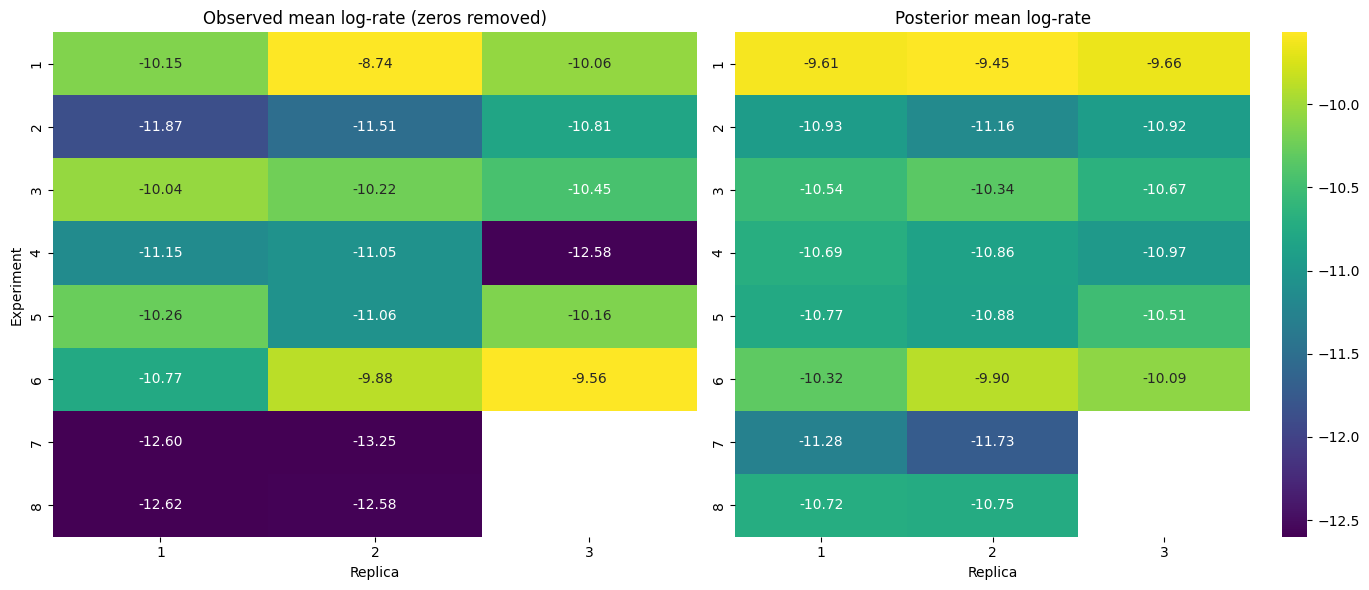

In [23]:
# -----------------------------
# 1) OBSERVED heatmap (zeros removed via mask)
# -----------------------------
df_obs = pd.DataFrame({
    "idx_experiment": glm_data["idx_experiment"][mask],
    "idx_experiment_replica": glm_data["idx_experiment_replica"][mask],
    "log_rate_obs": log_rate_data
})

H_obs = (
    df_obs
    .groupby(["idx_experiment", "idx_experiment_replica"])["log_rate_obs"]
    .mean()
    .unstack()
)

# -----------------------------
# 2) POSTERIOR MEAN heatmap
# -----------------------------
rate_mean = np.asarray(
    get_posterior_rate_means(
        models[("ab_baseline_simple_poi.stan", tuple({}.items()), "X")]["az"],
        models[("ab_baseline_simple_poi.stan", tuple({}.items()), "X")]["X"],
        glm_data["idx_experiment"],
        glm_data["idx_experiment_replica"]
    )
)

df_post = pd.DataFrame({
    "idx_experiment": glm_data["idx_experiment"],
    "idx_experiment_replica": glm_data["idx_experiment_replica"],
    "log_rate_post": rate_mean   # (se è già log-rate; se invece è rate, usa np.log(rate_mean))
})

H_post = (
    df_post
    .groupby(["idx_experiment", "idx_experiment_replica"])["log_rate_post"]
    .mean()
    .unstack()
)

# -----------------------------
# 3) Use SAME color scale for both (ROBUST)
# -----------------------------
all_vals = np.concatenate([H_obs.values.ravel(), H_post.values.ravel()])
all_vals = all_vals[np.isfinite(all_vals)]

vmin = np.percentile(all_vals, 5)
vmax = np.percentile(all_vals, 95)

# -----------------------------
# 4) Plot side-by-side with shared colorbar
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    H_obs, ax=axes[0],
    cmap="viridis", vmin=vmin, vmax=vmax,
    annot=True, fmt=".2f",
    cbar=False
)
axes[0].set_title("Observed mean log-rate (zeros removed)")
axes[0].set_xlabel("Replica")
axes[0].set_ylabel("Experiment")

sns.heatmap(
    H_post, ax=axes[1],
    cmap="viridis", vmin=vmin, vmax=vmax,
    annot=True, fmt=".2f",
    cbar=True
)
axes[1].set_title("Posterior mean log-rate")
axes[1].set_xlabel("Replica")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()




## Posterior log_rate mean on combination of DMSO and IBU when temp is low (28)

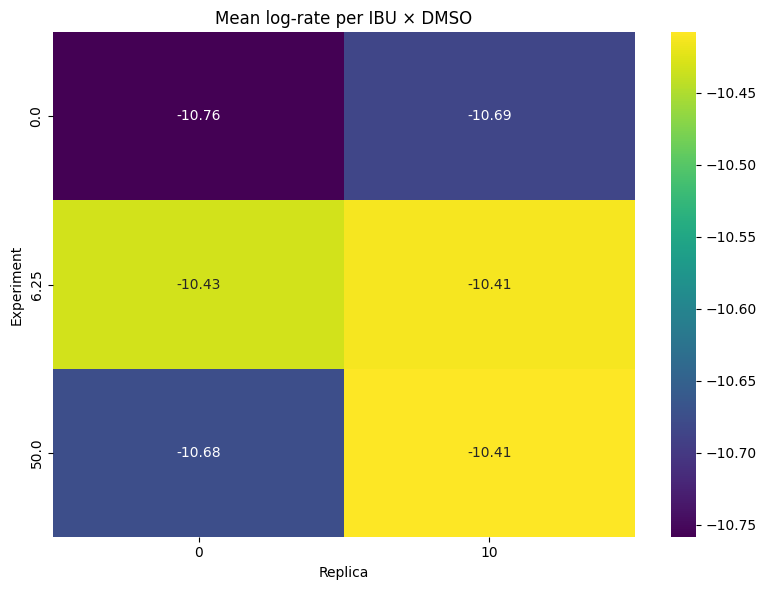

In [25]:
import seaborn as sns

df = pd.DataFrame({
    "idx_experiment": glm_data["idx_experiment"],
    "idx_experiment_replica": glm_data["idx_experiment_replica"],
    "Temp":data["Temp"],
    "IBU":data["IBU"],
    "DMSO":data["DMSO"],
    "log_rate_mean": np.asarray(
        get_posterior_rate_means(
            models[("ab_baseline_simple_poi.stan", tuple({}.items()), "X")]["az"], 
            models[("ab_baseline_simple_poi.stan", tuple({}.items()), "X")]["X"], 
            glm_data["idx_experiment"], 
            glm_data["idx_experiment_replica"]
        )
    )
})

# media per (experiment × replica) + trasformazione in matrice
heatmap_data = (
    df.groupby(["IBU", "DMSO"])["log_rate_mean"]
      .mean()
      .unstack()
)

plt.figure(figsize=(8,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Mean log-rate per IBU × DMSO")
plt.xlabel("Replica")
plt.ylabel("Experiment")
plt.tight_layout()
plt.show()

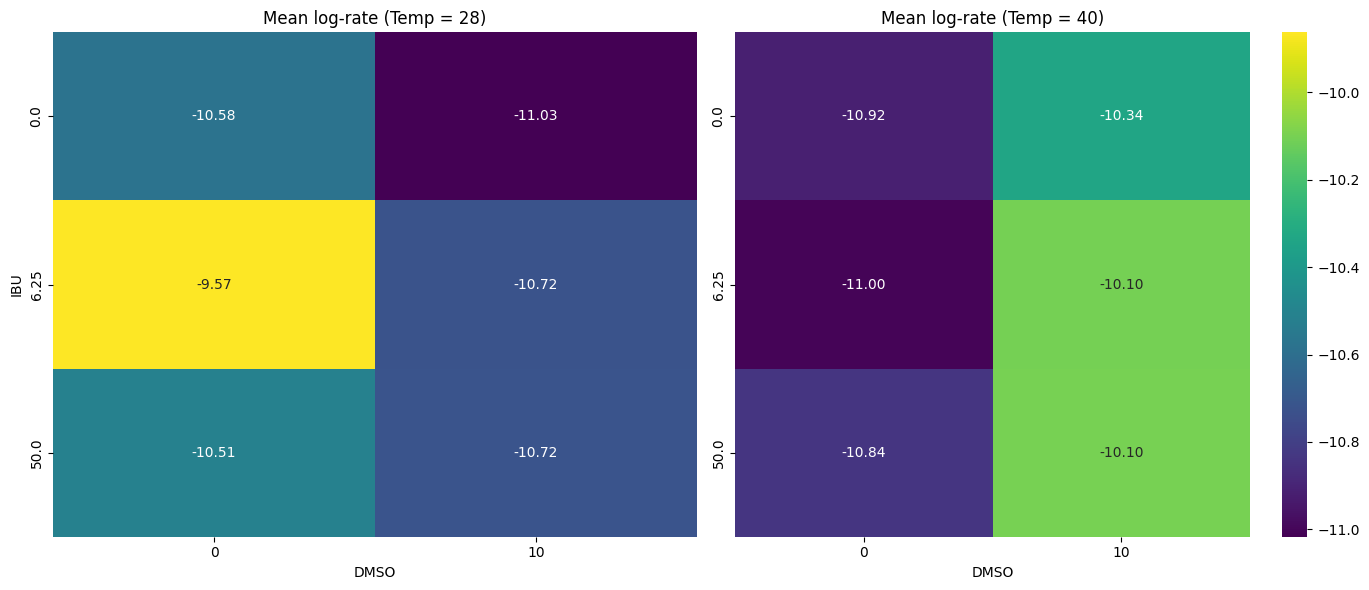

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Costruisci dataframe ----
df = pd.DataFrame({
    "idx_experiment": glm_data["idx_experiment"],
    "idx_experiment_replica": glm_data["idx_experiment_replica"],
    "Temp": data["Temp"],
    "IBU": data["IBU"],
    "DMSO": data["DMSO"],
    "log_rate_mean": np.asarray(
        get_posterior_rate_means(
            models[("ab_baseline_simple_poi.stan", tuple({}.items()), "X")]["az"], 
            models[("ab_baseline_simple_poi.stan", tuple({}.items()), "X")]["X"], 
            glm_data["idx_experiment"], 
            glm_data["idx_experiment_replica"]
        )
    )
})

# ---- Heatmap Temp = 28 ----
H_28 = (
    df[df["Temp"] == 28]
    .groupby(["IBU", "DMSO"])["log_rate_mean"]
    .mean()
    .unstack()
)

# ---- Heatmap Temp = 40 ----
H_40 = (
    df[df["Temp"] == 40]
    .groupby(["IBU", "DMSO"])["log_rate_mean"]
    .mean()
    .unstack()
)

# ---- Scala colori coerente ----
all_vals = np.concatenate([H_28.values.ravel(), H_40.values.ravel()])
all_vals = all_vals[np.isfinite(all_vals)]

vmin = np.percentile(all_vals, 5)
vmax = np.percentile(all_vals, 95)

# ---- Plot affiancato ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    H_28,
    ax=axes[0],
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    cbar=False
)
axes[0].set_title("Mean log-rate (Temp = 28)")
axes[0].set_xlabel("DMSO")
axes[0].set_ylabel("IBU")

sns.heatmap(
    H_40,
    ax=axes[1],
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title("Mean log-rate (Temp = 40)")
axes[1].set_xlabel("DMSO")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


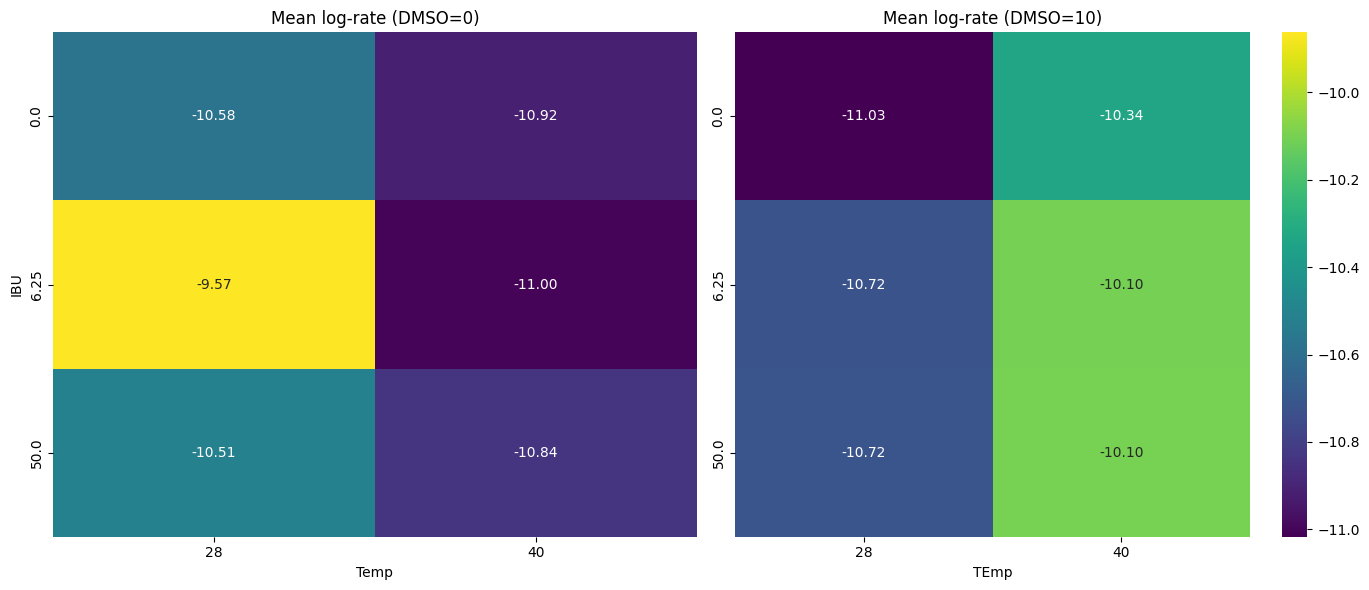

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Costruisci dataframe ----
df = pd.DataFrame({
    "idx_experiment": glm_data["idx_experiment"],
    "idx_experiment_replica": glm_data["idx_experiment_replica"],
    "Temp": data["Temp"],
    "IBU": data["IBU"],
    "DMSO": data["DMSO"],
    "log_rate_mean": np.asarray(
        get_posterior_rate_means(
            models[("ab_baseline_simple_poi.stan", tuple({}.items()), "X")]["az"], 
            models[("ab_baseline_simple_poi.stan", tuple({}.items()), "X")]["X"], 
            glm_data["idx_experiment"], 
            glm_data["idx_experiment_replica"]
        )
    )
})

# ---- Heatmap Temp = 28 ----
H_28 = (
    df[df["DMSO"] == 0]
    .groupby(["IBU", "Temp"])["log_rate_mean"]
    .mean()
    .unstack()
)

# ---- Heatmap Temp = 40 ----
H_40 = (
    df[df["DMSO"] == 10]
    .groupby(["IBU", "Temp"])["log_rate_mean"]
    .mean()
    .unstack()
)

# ---- Scala colori coerente ----
all_vals = np.concatenate([H_28.values.ravel(), H_40.values.ravel()])
all_vals = all_vals[np.isfinite(all_vals)]

vmin = np.percentile(all_vals, 5)
vmax = np.percentile(all_vals, 95)

# ---- Plot affiancato ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    H_28,
    ax=axes[0],
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    cbar=False
)
axes[0].set_title("Mean log-rate (DMSO=0)")
axes[0].set_xlabel("Temp")
axes[0].set_ylabel("IBU")

sns.heatmap(
    H_40,
    ax=axes[1],
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title("Mean log-rate (DMSO=10)")
axes[1].set_xlabel("TEmp")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()